### Import Modules, then Load & Clean Data, then Create Subsets of Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.impute import SimpleImputer

# Load data
spf_data = pd.read_csv("StudentPerformanceFactors.csv")

# Identify target and features
target = 'Exam_Score'
X_raw = spf_data.drop(columns=[target])
y = spf_data[target]

# Separate numerical and categorical columns
num_cols = X_raw.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_raw.select_dtypes(include=['object']).columns

# Impute numerical with median, categorical with most frequent (mode)
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# Create cleaned dataframes
X_num_imputed = pd.DataFrame(num_imputer.fit_transform(X_raw[num_cols]), columns=num_cols)
X_cat_imputed = pd.DataFrame(cat_imputer.fit_transform(X_raw[cat_cols]), columns=cat_cols)

# Recombine into a single cleaned feature set
X_cleaned = pd.concat([X_num_imputed, X_cat_imputed], axis=1)

# Define our three subsets for testing
X_quant = X_cleaned[num_cols]
X_qual = X_cleaned[cat_cols]
X_all = X_cleaned

---

### Linear Regression using Forwards Feature Selection


Forward Selection: Quantitative Features
Optimal Number of Features: 5 (Out of 6)
Selected Features: ['Attendance', 'Hours_Studied', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']
Out-of-Sample (Test) R-squared: 0.595
Out-of-Sample (Test) RMSE: 2.520


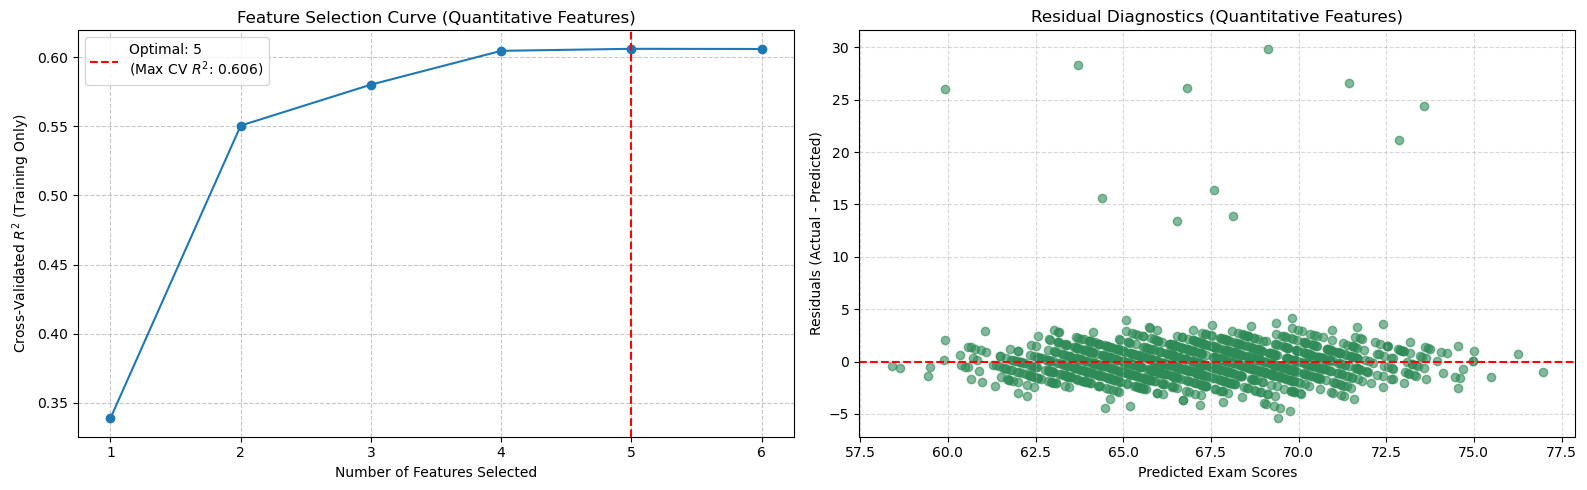


Forward Selection: Qualitative Features
Optimal Number of Features: 20 (Out of 21)
Selected Features: ['Access_to_Resources_Low', 'Parental_Involvement_Low', 'Parental_Involvement_Medium', 'Access_to_Resources_Medium', 'Parental_Education_Level_Postgraduate', 'Motivation_Level_Low', 'Learning_Disabilities_Yes', 'Distance_from_Home_Near', 'Family_Income_Low', 'Peer_Influence_Positive', 'Extracurricular_Activities_Yes', 'Peer_Influence_Neutral', 'Family_Income_Medium', 'Teacher_Quality_Low', 'Teacher_Quality_Medium', 'Distance_from_Home_Moderate', 'Parental_Education_Level_High School', 'Internet_Access_Yes', 'Motivation_Level_Medium', 'School_Type_Public']
Out-of-Sample (Test) R-squared: 0.115
Out-of-Sample (Test) RMSE: 3.725


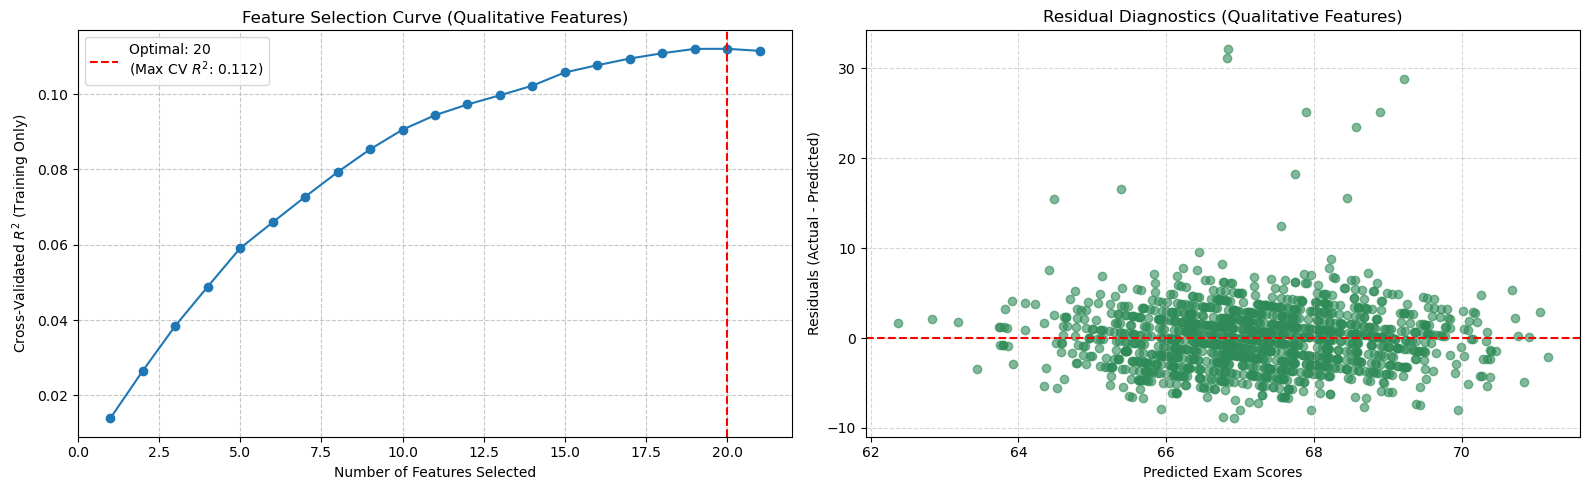


Forward Selection: All Features
Optimal Number of Features: 24 (Out of 27)
Selected Features: ['Attendance', 'Hours_Studied', 'Previous_Scores', 'Tutoring_Sessions', 'Access_to_Resources_Low', 'Parental_Involvement_Low', 'Parental_Involvement_Medium', 'Access_to_Resources_Medium', 'Peer_Influence_Positive', 'Family_Income_Low', 'Parental_Education_Level_Postgraduate', 'Distance_from_Home_Near', 'Motivation_Level_Low', 'Learning_Disabilities_Yes', 'Extracurricular_Activities_Yes', 'Internet_Access_Yes', 'Peer_Influence_Neutral', 'Teacher_Quality_Low', 'Teacher_Quality_Medium', 'Family_Income_Medium', 'Motivation_Level_Medium', 'Physical_Activity', 'Parental_Education_Level_High School', 'Distance_from_Home_Moderate']
Out-of-Sample (Test) R-squared: 0.726
Out-of-Sample (Test) RMSE: 2.072


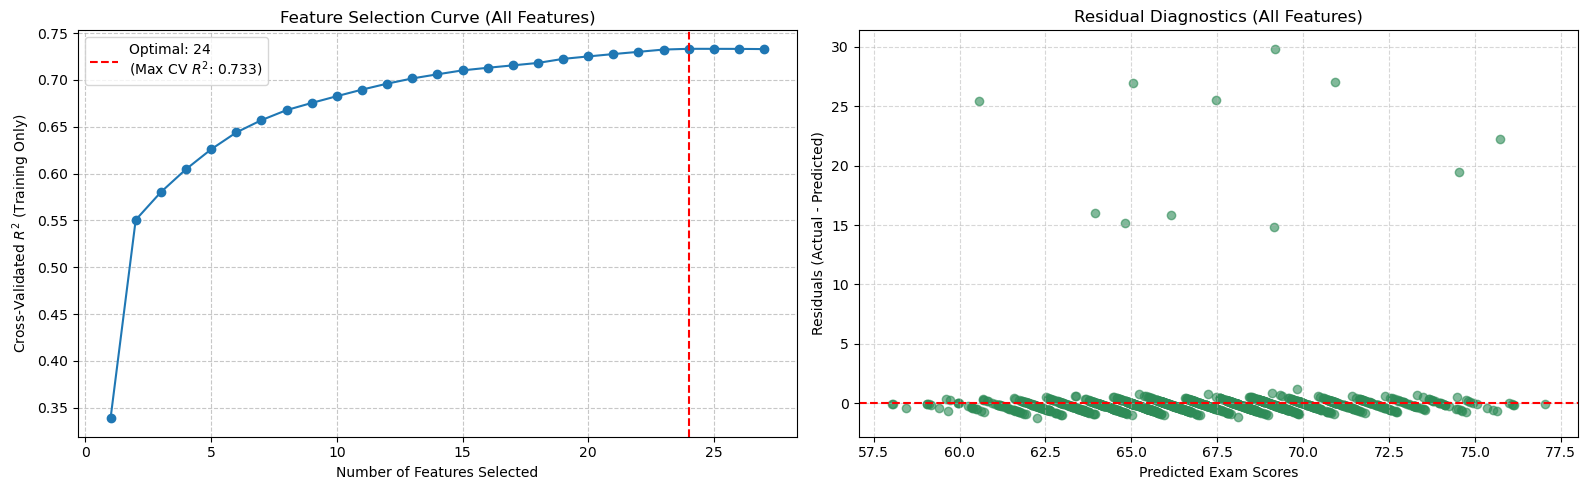

In [2]:
def plot_and_evaluate_forward_selection(X, y, feature_set_name):
    print(f"\n{'='*50}\nForward Selection: {feature_set_name}\n{'='*50}")
    
    # Encode categorical variables
    X_encoded = pd.get_dummies(X, drop_first=True)
    
    # Strict Train-Test Split BEFORE selection
    X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=12)
    
    total_features = X_train.shape[1]
    selected_features = []
    remaining_features = list(X_train.columns)
    cv_r2_scores = []
    
    lin_reg = LinearRegression()
    
    # Select based purely on Cross-Validated R^2
    for i in range(1, total_features + 1):
        best_cv_r2 = -np.inf
        best_feature = None
        
        for feature in remaining_features:
            test_features = selected_features + [feature]
            # CV evaluated ONLY on training data
            score = cross_val_score(lin_reg, X_train[test_features], y_train, cv=5, scoring='r2').mean()
            
            if score > best_cv_r2:
                best_cv_r2 = score
                best_feature = feature
                
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        cv_r2_scores.append(best_cv_r2)
        
    # Find the peak of the CV curve
    max_cv_r2 = max(cv_r2_scores)
    optimal_num = cv_r2_scores.index(max_cv_r2) + 1
    best_feature_names = selected_features[:optimal_num]
    
    print(f"Optimal Number of Features: {optimal_num} (Out of {total_features})")
    print(f"Selected Features: {best_feature_names}")
    
    # Train final model on optimally selected features
    lin_reg.fit(X_train[best_feature_names], y_train)
    y_pred = lin_reg.predict(X_test[best_feature_names])
    
    test_r2 = r2_score(y_test, y_pred)
    test_rmse = root_mean_squared_error(y_test, y_pred)
    
    print(f"Out-of-Sample (Test) R-squared: {test_r2:.3f}")
    print(f"Out-of-Sample (Test) RMSE: {test_rmse:.3f}")
    
    # Feature Selection Curve Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    ax1.plot(range(1, total_features + 1), cv_r2_scores, marker='o', linestyle='-')
    ax1.set_title(f'Feature Selection Curve ({feature_set_name})')
    ax1.set_xlabel('Number of Features Selected')
    ax1.set_ylabel('Cross-Validated $R^2$ (Training Only)')
    ax1.axvline(x=optimal_num, color='red', linestyle='--', 
                label=f'Optimal: {optimal_num}\n(Max CV $R^2$: {max_cv_r2:.3f})')
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend()
    
    # Residuals Plot
    residuals = y_test - y_pred
    ax2.scatter(y_pred, residuals, alpha=0.6, color='seagreen')
    ax2.axhline(0, color='red', linestyle='--')
    ax2.set_title(f'Residual Diagnostics ({feature_set_name})')
    ax2.set_xlabel('Predicted Exam Scores')
    ax2.set_ylabel('Residuals (Actual - Predicted)')
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# Execute the regression models
plot_and_evaluate_forward_selection(X_quant, y, "Quantitative Features")
plot_and_evaluate_forward_selection(X_qual, y, "Qualitative Features")
plot_and_evaluate_forward_selection(X_all, y, "All Features")

---

### Function for Linear Regression using Backwards Feature Selection


Backward Selection: Quantitative Features
Optimal Number of Features: 5 (Out of 6)
Selected Features: ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']
Out-of-Sample (Test) R-squared: 0.595
Out-of-Sample (Test) RMSE: 2.520


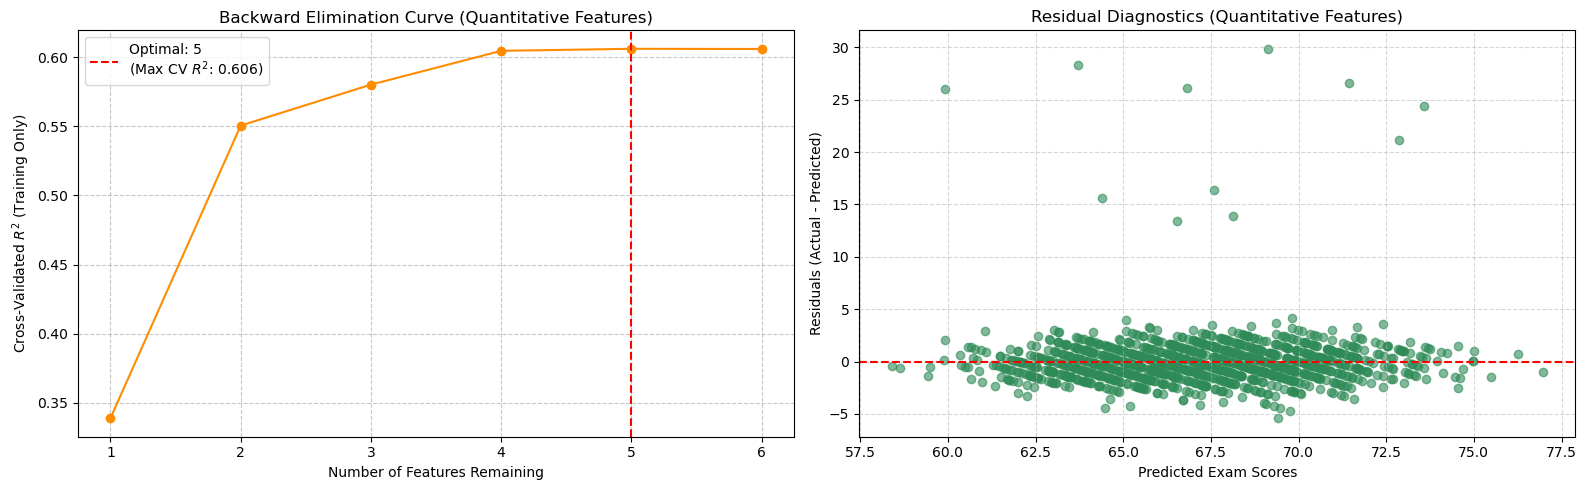


Backward Selection: Qualitative Features
Optimal Number of Features: 20 (Out of 21)
Selected Features: ['Parental_Involvement_Low', 'Parental_Involvement_Medium', 'Access_to_Resources_Low', 'Access_to_Resources_Medium', 'Extracurricular_Activities_Yes', 'Motivation_Level_Low', 'Motivation_Level_Medium', 'Internet_Access_Yes', 'Family_Income_Low', 'Family_Income_Medium', 'Teacher_Quality_Low', 'Teacher_Quality_Medium', 'School_Type_Public', 'Peer_Influence_Neutral', 'Peer_Influence_Positive', 'Learning_Disabilities_Yes', 'Parental_Education_Level_High School', 'Parental_Education_Level_Postgraduate', 'Distance_from_Home_Moderate', 'Distance_from_Home_Near']
Out-of-Sample (Test) R-squared: 0.115
Out-of-Sample (Test) RMSE: 3.725


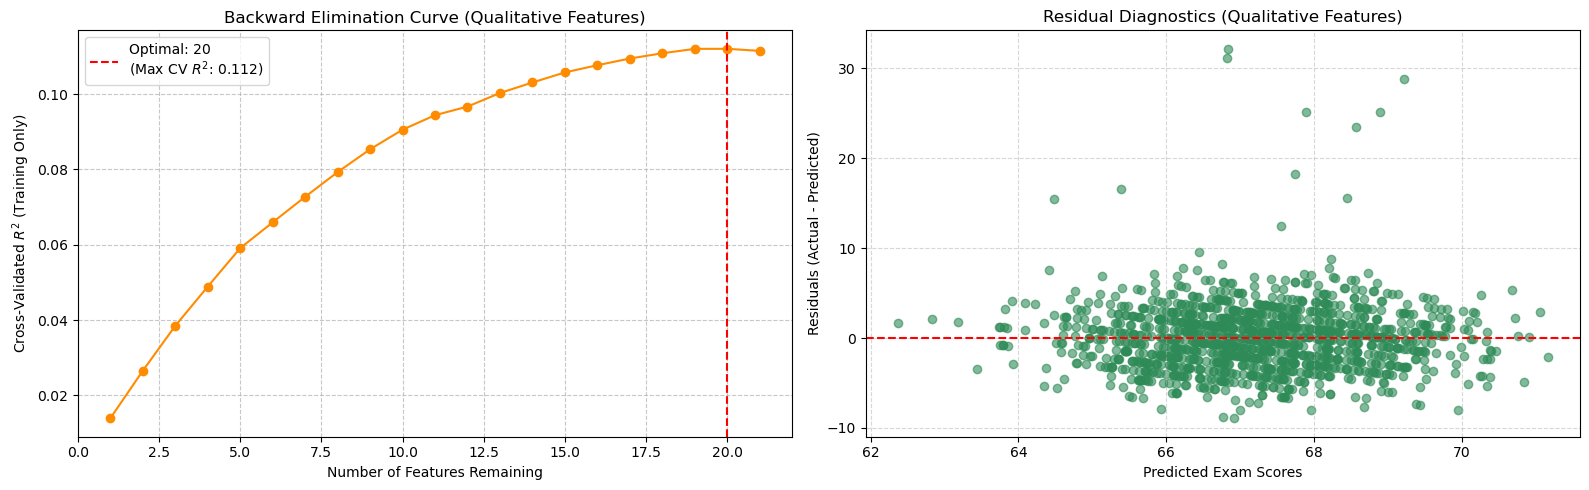


Backward Selection: All Features
Optimal Number of Features: 24 (Out of 27)
Selected Features: ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Parental_Involvement_Low', 'Parental_Involvement_Medium', 'Access_to_Resources_Low', 'Access_to_Resources_Medium', 'Extracurricular_Activities_Yes', 'Motivation_Level_Low', 'Motivation_Level_Medium', 'Internet_Access_Yes', 'Family_Income_Low', 'Family_Income_Medium', 'Teacher_Quality_Low', 'Teacher_Quality_Medium', 'Peer_Influence_Neutral', 'Peer_Influence_Positive', 'Learning_Disabilities_Yes', 'Parental_Education_Level_High School', 'Parental_Education_Level_Postgraduate', 'Distance_from_Home_Moderate', 'Distance_from_Home_Near']
Out-of-Sample (Test) R-squared: 0.726
Out-of-Sample (Test) RMSE: 2.072


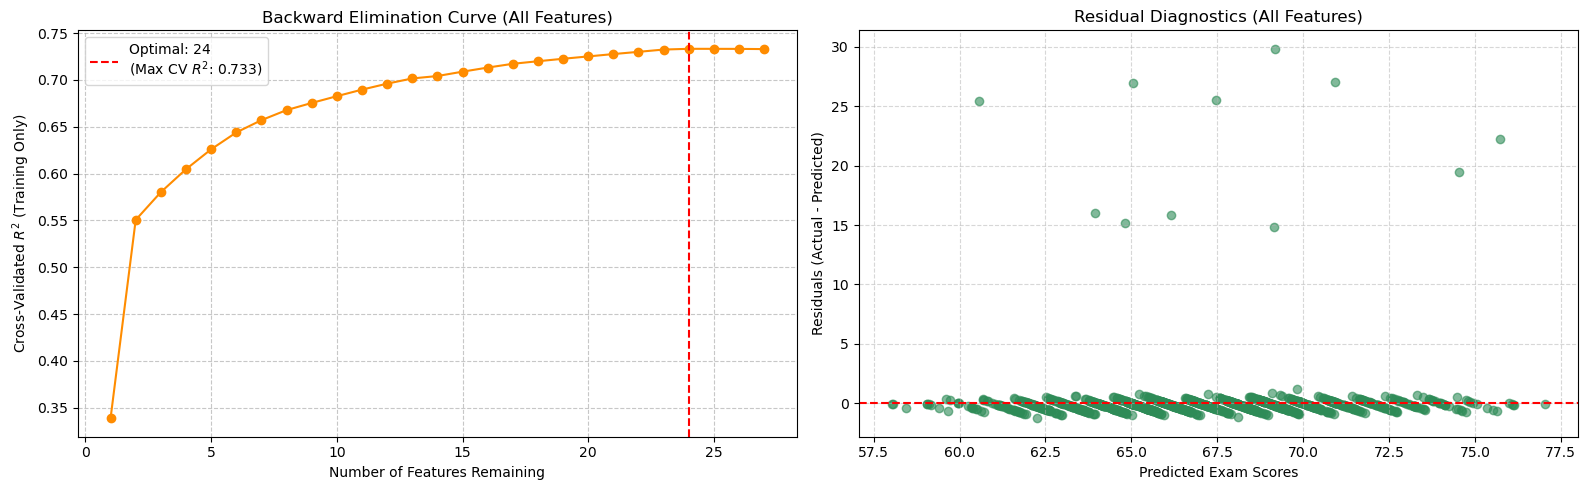

In [3]:
def plot_and_evaluate_backward_selection(X, y, feature_set_name):
    print(f"\n{'='*50}\nBackward Selection: {feature_set_name}\n{'='*50}")
    
    # Encode categorical variables
    X_encoded = pd.get_dummies(X, drop_first=True)
    
    # Strict Train-Test Split BEFORE selection to prevent data leakage
    X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=12)
    
    lin_reg = LinearRegression()
    current_features = list(X_train.columns)
    total_features = len(current_features)
    
    # Tracking variables
    cv_r2_scores = []
    feature_sets_history = []
    
    # Evaluate the baseline model with ALL features
    initial_score = cross_val_score(lin_reg, X_train[current_features], y_train, cv=5, scoring='r2').mean()
    cv_r2_scores.append(initial_score)
    feature_sets_history.append(list(current_features))
    
    # Iteratively drop one feature at a time
    for i in range(total_features - 1, 0, -1):
        best_cv_r2 = -np.inf
        feature_to_drop = None
        
        # Test dropping each remaining feature
        for feature in current_features:
            test_features = [f for f in current_features if f != feature]
            score = cross_val_score(lin_reg, X_train[test_features], y_train, cv=5, scoring='r2').mean()
            
            # Find the feature whose removal results in the highest remaining CV score
            if score > best_cv_r2:
                best_cv_r2 = score
                feature_to_drop = feature
                
        # Drop the worst-performing feature from the current pool
        current_features.remove(feature_to_drop)
        cv_r2_scores.append(best_cv_r2)
        feature_sets_history.append(list(current_features))
        
    # Reverse the histories so the x-axis reads from 1 up to total_features (matching the forward selection plot)
    cv_r2_scores.reverse()
    feature_sets_history.reverse()
    
    # Find the peak of the CV curve
    max_cv_r2 = max(cv_r2_scores)
    optimal_index = cv_r2_scores.index(max_cv_r2)
    optimal_num = optimal_index + 1
    best_feature_names = feature_sets_history[optimal_index]
    
    print(f"Optimal Number of Features: {optimal_num} (Out of {total_features})")
    print(f"Selected Features: {best_feature_names}")
    
    # Train final model on optimally selected features
    lin_reg.fit(X_train[best_feature_names], y_train)
    y_pred = lin_reg.predict(X_test[best_feature_names])
    
    test_r2 = r2_score(y_test, y_pred)
    test_rmse = root_mean_squared_error(y_test, y_pred)
    
    print(f"Out-of-Sample (Test) R-squared: {test_r2:.3f}")
    print(f"Out-of-Sample (Test) RMSE: {test_rmse:.3f}")
    
    # Feature Selection Curve Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    ax1.plot(range(1, total_features + 1), cv_r2_scores, marker='o', linestyle='-', color='darkorange')
    ax1.set_title(f'Backward Elimination Curve ({feature_set_name})')
    ax1.set_xlabel('Number of Features Remaining')
    ax1.set_ylabel('Cross-Validated $R^2$ (Training Only)')
    ax1.axvline(x=optimal_num, color='red', linestyle='--', 
                label=f'Optimal: {optimal_num}\n(Max CV $R^2$: {max_cv_r2:.3f})')
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend()
    
    # Residuals Plot
    residuals = y_test - y_pred
    ax2.scatter(y_pred, residuals, alpha=0.6, color='seagreen')
    ax2.axhline(0, color='red', linestyle='--')
    ax2.set_title(f'Residual Diagnostics ({feature_set_name})')
    ax2.set_xlabel('Predicted Exam Scores')
    ax2.set_ylabel('Residuals (Actual - Predicted)')
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

plot_and_evaluate_backward_selection(X_quant, y, "Quantitative Features")
plot_and_evaluate_backward_selection(X_qual, y, "Qualitative Features")
plot_and_evaluate_backward_selection(X_all, y, "All Features")

---

### Function for Pruned Random Forest Regressor using Train-Test Split

In [4]:
def evaluate_pruned_random_forest(X, y, feature_set_name):
    print(f"\n{'='*50}\nRandom Forest Pruning: {feature_set_name}\n{'='*50}")
    
    X_encoded = pd.get_dummies(X, drop_first=True)
    X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=12)
    
    rf = RandomForestRegressor(random_state=12, n_jobs=-1)
    
    # Grid Search for optimal complexity penalty (ccp_alpha)
    param_grid = {'ccp_alpha': np.linspace(0, 0.05, 10)}
    grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    
    print("Running Grid Search...")
    grid_search.fit(X_train, y_train)
    best_rf = grid_search.best_estimator_
    
    print(f"Best ccp_alpha: {grid_search.best_params_['ccp_alpha']:.4f}")
    
    # Evaluate final model on the independent test set
    y_pred = best_rf.predict(X_test)
    test_r2 = r2_score(y_test, y_pred)
    test_rmse = root_mean_squared_error(y_test, y_pred)
    
    print(f"Test Set R-squared: {test_r2:.3f}")
    print(f"Test Set RMSE: {test_rmse:.3f}")

# Execute the tree models
evaluate_pruned_random_forest(X_quant, y, "Quantitative Features")
evaluate_pruned_random_forest(X_qual, y, "Qualitative Features")
evaluate_pruned_random_forest(X_all, y, "All Features")


Random Forest Pruning: Quantitative Features
Running Grid Search...
Best ccp_alpha: 0.0056
Test Set R-squared: 0.536
Test Set RMSE: 2.696

Random Forest Pruning: Qualitative Features
Running Grid Search...
Best ccp_alpha: 0.0500
Test Set R-squared: 0.076
Test Set RMSE: 3.806

Random Forest Pruning: All Features
Running Grid Search...
Best ccp_alpha: 0.0000
Test Set R-squared: 0.620
Test Set RMSE: 2.439


---

### Function for Random Forest Regressor using 5-Fold CV

In [5]:
def evaluate_unpruned_random_forest(X, y, feature_set_name):
    print(f"\n{'='*60}\nUnpruned Random Forest 5-Fold CV: {feature_set_name}\n{'='*60}")

    X_encoded = pd.get_dummies(X, drop_first=True)
    
    # Create the random forest regressor object
    tree_reg_model = RandomForestRegressor(random_state=12, n_jobs=-1)
    
    # Use k-fold cross validation to calculate R^2 and RMSE scores of different subsets
    cv_r2_scores = cross_val_score(tree_reg_model, X_encoded, y, cv=5, scoring='r2')
    cv_neg_mse_scores = cross_val_score(tree_reg_model, X_encoded, y, cv=5, scoring='neg_mean_squared_error')
    cv_rmse_scores = np.sqrt(-cv_neg_mse_scores)
    
    # Print results
    print(f"Individual R-squared scores: {cv_r2_scores.round(3)}")
    print(f"Average R-squared: {round(cv_r2_scores.mean(),3)} (Standard Deviation: +/- {round(cv_r2_scores.std(),3)})")
    print(f"Individual RMSE scores: {cv_rmse_scores.round(3)}")
    print(f"Average RMSE: {round(cv_rmse_scores.mean(),3)} (Standard Deviation: +/- {round(cv_rmse_scores.std(),3)})")

evaluate_unpruned_random_forest(X_quant, y, "Quantitative Features")
evaluate_unpruned_random_forest(X_qual, y, "Qualitative Features")
evaluate_unpruned_random_forest(X_all, y, "All Features")


Unpruned Random Forest 5-Fold CV: Quantitative Features
Individual R-squared scores: [0.45  0.494 0.523 0.546 0.599]
Average R-squared: 0.522 (Standard Deviation: +/- 0.05)
Individual RMSE scores: [2.939 2.786 2.677 2.62  2.407]
Average RMSE: 2.686 (Standard Deviation: +/- 0.177)

Unpruned Random Forest 5-Fold CV: Qualitative Features
Individual R-squared scores: [-0.076 -0.055 -0.01  -0.05  -0.091]
Average R-squared: -0.056 (Standard Deviation: +/- 0.027)
Individual RMSE scores: [4.109 4.022 3.894 3.986 3.97 ]
Average RMSE: 3.996 (Standard Deviation: +/- 0.07)

Unpruned Random Forest 5-Fold CV: All Features
Individual R-squared scores: [0.532 0.613 0.599 0.639 0.695]
Average R-squared: 0.616 (Standard Deviation: +/- 0.053)
Individual RMSE scores: [2.71  2.437 2.453 2.336 2.098]
Average RMSE: 2.407 (Standard Deviation: +/- 0.198)


---